In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import LinearSVC

from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import joblib
import os

In [5]:
df = pd.read_csv("fake_job_postings.csv")

df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [6]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["fraudulent"].value_counts())

Dataset shape: (17880, 18)

Columns:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

Missing values:
job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

Target distribution:
fraudulent
0    17014
1      866
Name: count, dtype: int64


In [7]:
df = df.drop(columns=["job_id", "salary_range"])

print("New shape:", df.shape)
print(df.columns.tolist())

New shape: (17880, 16)
['title', 'location', 'department', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


In [8]:
# Separate the input features from the target column
# X contains all columns that will be used to make predictions
X = df.drop(columns=["fraudulent"])

# y contains the target variable
# 0 = legitimate job posting
# 1 = fraudulent job posting
y = df["fraudulent"]

# Display the dimensions of X and y
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (17880, 15)
Target (y) shape: (17880,)


In [9]:
# ---------------------------------------------------------
# STEP 5: DEFINE FEATURE GROUPS
# ---------------------------------------------------------

# later convert this text into numerical TF-IDF features.
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

# Categorical columns
# later convert them using One-Hot Encoding.
categorical_columns = [
    "location",
    "department",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

# Numeric/binary columns
numeric_columns = [
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

# Display the feature groups
print("Text columns:")
print(text_columns)

print("\nCategorical columns:")
print(categorical_columns)

print("\nNumeric/Binary columns:")
print(numeric_columns)

Text columns:
['title', 'company_profile', 'description', 'requirements', 'benefits']

Categorical columns:
['location', 'department', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']

Numeric/Binary columns:
['telecommuting', 'has_company_logo', 'has_questions']


In [10]:
# ---------------------------------------------------------
# STEP 6: COMBINE ALL TEXT COLUMNS
# ---------------------------------------------------------

# Make a copy of X so that we can safely modify the features
X = X.copy()

# Replace missing values in the text columns with empty strings.
X[text_columns] = X[text_columns].fillna("")

# Combine all five text columns into one column.
X["combined_text"] = X[text_columns].agg(" ".join, axis=1)

# Display the first combined text entry
print("First combined text:")
print(X["combined_text"].iloc[0])

# Check whether any missing values remain in combined_text
print("\nMissing values in combined_text:")
print(X["combined_text"].isnull().sum())

First combined text:
Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributors in the country; we also publish well-known professionals like Mario Batali, Gwyneth Paltrow, and Danny Meyer. And we have partnerships with Whole Foods Market and Random House.Food52 has been named the best food website by the James Beard Foundation and IACP, and has been featured in the New York Times, NPR, Pando Daily, TechCrunch, and on the Today Show.We're located in Chelsea, in New York City. Food52, a fast-growing, James Beard Award-winning online food community and 

In [11]:
# ---------------------------------------------------------
# STEP 7: REMOVE ORIGINAL TEXT COLUMNS
# ---------------------------------------------------------

X = X.drop(columns=text_columns)

# Display the remaining columns
print("Remaining columns:")
print(X.columns.tolist())

# Display the shape of the feature dataset
print("\nFeature shape:", X.shape)

Remaining columns:
['location', 'department', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'combined_text']

Feature shape: (17880, 11)


In [12]:
# ---------------------------------------------------------
# STEP 8: SPLIT DATA INTO TRAINING AND TESTING SETS
# ---------------------------------------------------------

from sklearn.model_selection import train_test_split

# Split the feature data (X) and target data (y)
# 80% of the data will be used for training
# 20% of the data will be used for testing

# stratify=y keeps the proportion of legitimate and
# fraudulent jobs approximately the same in both sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the size of each dataset
print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (14304, 11)
y_train: (14304,)

Testing data:
X_test: (3576, 11)
y_test: (3576,)


In [13]:
# ---------------------------------------------------------
# STEP 9: CREATE TF-IDF VECTORIZER
# ---------------------------------------------------------

# Create the TF-IDF vectorizer.
# Converts all text to lowercase
# max_features=50000:
# Limits the vocabulary to the 50,000 most useful features.
#
# ngram_range=(1, 2):
# Uses both individual words (unigrams) and pairs of words
# (bigrams).


tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=50000,
    ngram_range=(1, 2)
)

print("TF-IDF vectorizer created successfully.")

TF-IDF vectorizer created successfully.


In [14]:
# ---------------------------------------------------------
# STEP 10: FIT TF-IDF ON TRAINING DATA
# ---------------------------------------------------------

# Learn the vocabulary and IDF values only from the
# training text.

X_train_text = tfidf.fit_transform(X_train["combined_text"])

X_test_text = tfidf.transform(X_test["combined_text"])

# Display the resulting matrix sizes
print("X_train_text shape:", X_train_text.shape)
print("X_test_text shape:", X_test_text.shape)

X_train_text shape: (14304, 50000)
X_test_text shape: (3576, 50000)


In [15]:
# ---------------------------------------------------------
# STEP 11: CREATE ONE-HOT ENCODER
# ---------------------------------------------------------

# Create a preprocessing pipeline for categorical features.
#
# Step 1:
# Replace missing categorical values with "Unknown".
#
# Step 2:
# Convert categorical values into numerical columns
# using One-Hot Encoding.

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Unknown"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

print("Categorical preprocessing pipeline created successfully.")

Categorical preprocessing pipeline created successfully.


In [16]:
# ---------------------------------------------------------
# STEP 12: ENCODE CATEGORICAL FEATURES
# ---------------------------------------------------------

# Fit the encoder using ONLY the training data.
# This learns all the categorical values present in
# the training set.
X_train_cat = categorical_pipeline.fit_transform(
    X_train[categorical_columns]
)

# Transform the test data using the encoder already
# learned from the training data.
X_test_cat = categorical_pipeline.transform(
    X_test[categorical_columns]
)

# Display the dimensions of the encoded data
print("X_train_cat shape:", X_train_cat.shape)
print("X_test_cat shape:", X_test_cat.shape)

X_train_cat shape: (14304, 4111)
X_test_cat shape: (3576, 4111)


In [17]:
# ---------------------------------------------------------
# STEP 13: PREPARE NUMERIC/BINARY FEATURES
# ---------------------------------------------------------

# Select the three numeric/binary columns from the
# training and testing datasets.
X_train_num = X_train[numeric_columns].values
X_test_num = X_test[numeric_columns].values

# Display their shapes
print("X_train_num shape:", X_train_num.shape)
print("X_test_num shape:", X_test_num.shape)

X_train_num shape: (14304, 3)
X_test_num shape: (3576, 3)


In [18]:
# ---------------------------------------------------------
# STEP 14: COMBINE ALL FEATURE TYPES
# ---------------------------------------------------------

# Convert the numeric features into a sparse matrix.
X_train_num_sparse = csr_matrix(X_train_num)
X_test_num_sparse = csr_matrix(X_test_num)

# Combine TF-IDF, One-Hot encoded, and numeric features
# horizontally to create the final feature matrix.
X_train_final = hstack([
    X_train_text,
    X_train_cat,
    X_train_num_sparse
]).tocsr()

X_test_final = hstack([
    X_test_text,
    X_test_cat,
    X_test_num_sparse
]).tocsr()

# Display the final feature matrix dimensions
print("Final training feature matrix:", X_train_final.shape)
print("Final testing feature matrix:", X_test_final.shape)

Final training feature matrix: (14304, 54114)
Final testing feature matrix: (3576, 54114)


In [19]:
# ---------------------------------------------------------
# STEP 15: CREATE THE SVM CLASSIFIER
# ---------------------------------------------------------

# C controls the strength of regularization.
# C=1.0 is our starting value.
#
# class_weight="balanced" gives more importance to the
# minority class (fraudulent job postings), because the
# dataset contains far fewer fraudulent jobs than
# legitimate jobs.
#
# random_state=42 makes the model reproducible.

svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42
)

print("SVM model created successfully.")

SVM model created successfully.


In [21]:
# ---------------------------------------------------------
# STEP 16: TRAIN THE SVM MODEL
# ---------------------------------------------------------

print("Training SVM...")

# Train the SVM using the final training feature matrix
# and the corresponding target values.
svm_model.fit(X_train_final, y_train)

print("SVM training completed successfully.")

Training SVM...
SVM training completed successfully.


In [22]:
# ---------------------------------------------------------
# STEP 17: MAKE PREDICTIONS ON TEST DATA
# ---------------------------------------------------------

# Use the trained SVM to predict whether each test job
# posting is legitimate (0) or fraudulent (1).
y_pred = svm_model.predict(X_test_final)

# Display the first 20 predictions
print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [23]:
# ---------------------------------------------------------
# STEP 18: CHECK PREDICTION DISTRIBUTION
# ---------------------------------------------------------

# Count how many test samples were predicted as each class.
prediction_counts = pd.Series(y_pred).value_counts().sort_index()

print("Prediction distribution:")
print(prediction_counts)

# Display the counts separately
print("\nLegitimate predictions (0):", prediction_counts.get(0, 0))
print("Fraudulent predictions (1):", prediction_counts.get(1, 0))

Prediction distribution:
0    3411
1     165
Name: count, dtype: int64

Legitimate predictions (0): 3411
Fraudulent predictions (1): 165


In [24]:
# ---------------------------------------------------------
# STEP 19: CALCULATE CLASSIFICATION METRICS
# ---------------------------------------------------------

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calculate Precision
precision = precision_score(y_test, y_pred)

# Calculate Recall
recall = recall_score(y_test, y_pred)

# Calculate F1-score
# F1-score is the harmonic mean of Precision and Recall.
f1 = f1_score(y_test, y_pred)

# Display the results
print("SVM Evaluation Metrics")
print("----------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

SVM Evaluation Metrics
----------------------
Accuracy : 0.9922
Precision: 0.9394
Recall   : 0.8960
F1-score : 0.9172


In [25]:
# ---------------------------------------------------------
# STEP 20: CALCULATE ROC-AUC
# ---------------------------------------------------------
y_scores = svm_model.decision_function(X_test_final)

# Calculate the ROC-AUC score using the actual test
# labels and the SVM decision scores.
roc_auc = roc_auc_score(y_test, y_scores)

# Display ROC-AUC
print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.9898


In [26]:
# ---------------------------------------------------------
# STEP 21: CREATE CONFUSION MATRIX
# ---------------------------------------------------------

# Calculate the confusion matrix using the actual test
# labels and the SVM predictions.
cm = confusion_matrix(y_test, y_pred)

# Display the four confusion matrix values
print("Confusion Matrix:")
print(cm)

# Extract individual values from the matrix
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix Details:")
print("True Negatives (TN) :", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP) :", tp)

Confusion Matrix:
[[3393   10]
 [  18  155]]

Confusion Matrix Details:
True Negatives (TN) : 3393
False Positives (FP): 10
False Negatives (FN): 18
True Positives (TP) : 155


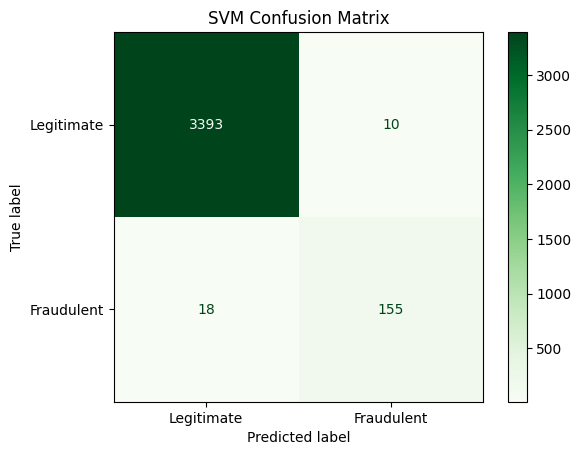

In [27]:
# ---------------------------------------------------------
# STEP 22: PLOT CONFUSION MATRIX
# ---------------------------------------------------------

# Create a confusion matrix display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraudulent"]
)

# Plot using a blue color map
disp.plot(cmap="Greens")

# Add title
plt.title("SVM Confusion Matrix")

# Display the plot
plt.show()

In [28]:
# ---------------------------------------------------------
# STEP 23: GENERATE CLASSIFICATION REPORT
# ---------------------------------------------------------

# Generate a detailed classification report.
#
# The report calculates Precision, Recall, F1-score,
# and Support separately for:
# 0 = Legitimate
# 1 = Fraudulent

report = classification_report(
    y_test,
    y_pred,
    target_names=["Legitimate", "Fraudulent"]
)

# Display the classification report
print("SVM Classification Report")
print("-------------------------")
print(report)

SVM Classification Report
-------------------------
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      1.00      3403
  Fraudulent       0.94      0.90      0.92       173

    accuracy                           0.99      3576
   macro avg       0.97      0.95      0.96      3576
weighted avg       0.99      0.99      0.99      3576



In [29]:
# ---------------------------------------------------------
# STEP 24: FINAL SVM RESULTS SUMMARY
# ---------------------------------------------------------

# Store all important SVM evaluation metrics
svm_results = {
    "Model": "SVM",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "ROC-AUC": roc_auc
}

# Convert the results into a DataFrame
results_df = pd.DataFrame([svm_results])

# Convert metric values from decimal to percentage
results_df["Accuracy"] = results_df["Accuracy"] * 100
results_df["Precision"] = results_df["Precision"] * 100
results_df["Recall"] = results_df["Recall"] * 100
results_df["F1-score"] = results_df["F1-score"] * 100
results_df["ROC-AUC"] = results_df["ROC-AUC"] * 100

# Round the values to two decimal places
results_df = results_df.round(2)

# Display the final SVM results
print("Final SVM Results")
print("=================")

display(results_df)

Final SVM Results


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,SVM,99.22,93.94,89.6,91.72,98.98


In [30]:
# Step 25: Save the trained SVM model

# Create the models directory if it does not already exist
os.makedirs("models", exist_ok=True)

# Save the trained SVM model
joblib.dump(svm_model, "models/svm.pkl")

print("SVM model saved successfully!")
print("Saved to: models/svm.pkl")

SVM model saved successfully!
Saved to: models/svm.pkl


In [31]:
# ---------------------------------------------------------
# STEP 26: VERIFY THE SAVED SVM MODEL
# ---------------------------------------------------------

# Load the saved SVM model
loaded_svm = joblib.load("models/svm.pkl")

# Use the loaded model to predict the test data
loaded_predictions = loaded_svm.predict(X_test_final)

# Check whether the predictions are identical
same_predictions = np.array_equal(y_pred, loaded_predictions)

print("Saved model loaded successfully!")
print("Predictions match:", same_predictions)

Saved model loaded successfully!
Predictions match: True


In [32]:
!git branch --show-current

fatal: not a git repository (or any of the parent directories): .git


In [34]:
# Move into the cloned GitHub repository
%cd /content/fake-job-detection-ml

# Check the current Git branch
!git branch --show-current

[Errno 2] No such file or directory: '/content/fake-job-detection-ml'
/content
fatal: not a git repository (or any of the parent directories): .git


In [35]:
# Step 27: Clone the team GitHub repository

!git clone https://github.com/sanath2003git/fake-job-detection-ml.git

Cloning into 'fake-job-detection-ml'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 32 (delta 15), reused 23 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 134.76 KiB | 3.37 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [36]:
# Step 28: Enter the team repository and check the current branch

%cd /content/fake-job-detection-ml

!git status
!git branch --show-current

/content/fake-job-detection-ml
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
main


In [37]:
# Step 29: Create the SVM feature branch

!git checkout -b feature/svm

# Verify the current branch
!git branch --show-current

Switched to a new branch 'feature/svm'
feature/svm


In [38]:
# Step 30: Check .gitignore

!cat .gitignore

# Python
__pycache__/
*.py[cod]

# Virtual environment
venv/
.venv/
env/

# Jupyter
.ipynb_checkpoints/

# VS Code
.vscode/

# Machine Learning
*.pkl
*.joblib

# Dataset
dataset/*.csv

# OS
.DS_Store
Thumbs.db

In [39]:
# Step 31: Check whether the SVM notebook file exists

!ls -lh /content/*.ipynb

ls: cannot access '/content/*.ipynb': No such file or directory
